# NYC Taxi Demand Forecasting - Time Series Analysis

This notebook builds a time series model to predict taxi demand based on historical trip data.

## Objectives:
1. Load and preprocess taxi trip data
2. Aggregate trips into time series (hourly/daily demand)
3. Perform exploratory time series analysis
4. Build multiple forecasting models (ARIMA, SARIMA, Prophet, LSTM)
5. Evaluate and compare model performance
6. Generate future demand predictions

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Data Loading and Preprocessing

In [2]:
# Load the data
print("Loading taxi trip data...")
df = pd.read_csv('train.csv', parse_dates=['pickup_datetime', 'dropoff_datetime'])
print(f"Data loaded: {len(df):,} records")
print(f"Date range: {df['pickup_datetime'].min()} to {df['pickup_datetime'].max()}")
df.head()

Loading taxi trip data...
Data loaded: 1,458,644 records
Date range: 2016-01-01 00:00:17 to 2016-06-30 23:59:39


,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


In [3]:
# Data info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype         
---  ------              --------------    -----         
 0   id                  1458644 non-null  object        
 1   vendor_id           1458644 non-null  int64         
 2   pickup_datetime     1458644 non-null  datetime64[ns]
 3   dropoff_datetime    1458644 non-null  datetime64[ns]
 4   passenger_count     1458644 non-null  int64         
 5   pickup_longitude    1458644 non-null  float64       
 6   pickup_latitude     1458644 non-null  float64       
 7   dropoff_longitude   1458644 non-null  float64       
 8   dropoff_latitude    1458644 non-null  float64       
 9   store_and_fwd_flag  1458644 non-null  object        
 10  trip_duration       1458644 non-null  int64         
dtypes: datetime64[ns](2), float64(4), int64(3), object(2)
memory usage: 122.4+ MB


In [4]:
# Basic statistics
df.describe()

,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration
count,1.458644e+06,1458644,1458644,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06
mean,1.534950e+00,2016-04-01 10:10:24.940037120,2016-04-01 10:26:24.432310528,1.664530e+00,-7.397349e+01,4.075092e+01,-7.397342e+01,4.075180e+01,9.594923e+02
min,1.000000e+00,2016-01-01 00:00:17,2016-01-01 00:03:31,0.000000e+00,-1.219333e+02,3.435970e+01,-1.219333e+02,3.218114e+01,1.000000e+00
25%,1.000000e+00,2016-02-17 16:46:04.249999872,2016-02-17 17:05:32.500000,1.000000e+00,-7.399187e+01,4.073735e+01,-7.399133e+01,4.073588e+01,3.970000e+02
50%,2.000000e+00,2016-04-01 17:19:40,2016-04-01 17:35:12,1.000000e+00,-7.398174e+01,4.075410e+01,-7.397975e+01,4.075452e+01,6.620000e+02
75%,2.000000e+00,2016-05-15 03:56:08.750000128,2016-05-15 04:10:51.750000128,2.000000e+00,-7.396733e+01,4.076836e+01,-7.396301e+01,4.076981e+01,1.075000e+03
max,2.000000e+00,2016-06-30 23:59:39,2016-07-01 23:02:03,9.000000e+00,-6.133553e+01,5.188108e+01,-6.133553e+01,4.392103e+01,3.526282e+06
std,4.987772e-01,NaN,NaN,1.314242e+00,7.090186e-02,3.288119e-02,7.064327e-02,3.589056e-02,5.237432e+03


## 2. Create Time Series: Aggregate Demand by Time Period

In [5]:
# Aggregate trips by hour (Hourly demand)
df['pickup_hour'] = df['pickup_datetime'].dt.floor('H')
hourly_demand = df.groupby('pickup_hour').size().reset_index(name='trip_count')
hourly_demand.columns = ['datetime', 'demand']
hourly_demand = hourly_demand.set_index('datetime').sort_index()

print(f"Hourly demand time series created: {len(hourly_demand)} hours")
print(f"Date range: {hourly_demand.index.min()} to {hourly_demand.index.max()}")
print(f"\nBasic statistics:")
print(hourly_demand.describe())

Hourly demand time series created: 4359 hours
Date range: 2016-01-01 00:00:00 to 2016-06-30 23:00:00

Basic statistics:
            demand
count  4359.000000
mean    334.628126
std     150.686660
min       1.000000
25%     224.500000
50%     376.000000
75%     443.000000
max     655.000000


In [6]:
# Create daily demand as well
df['pickup_date'] = df['pickup_datetime'].dt.date
daily_demand = df.groupby('pickup_date').size().reset_index(name='trip_count')
daily_demand.columns = ['date', 'demand']
daily_demand['date'] = pd.to_datetime(daily_demand['date'])
daily_demand = daily_demand.set_index('date').sort_index()

print(f"Daily demand time series created: {len(daily_demand)} days")
print(f"\nBasic statistics:")
print(daily_demand.describe())

Daily demand time series created: 182 days

Basic statistics:
            demand
count   182.000000
mean   8014.527473
std     925.767089
min    1648.000000
25%    7620.500000
50%    8091.000000
75%    8535.000000
max    9796.000000


## 3. Exploratory Time Series Analysis

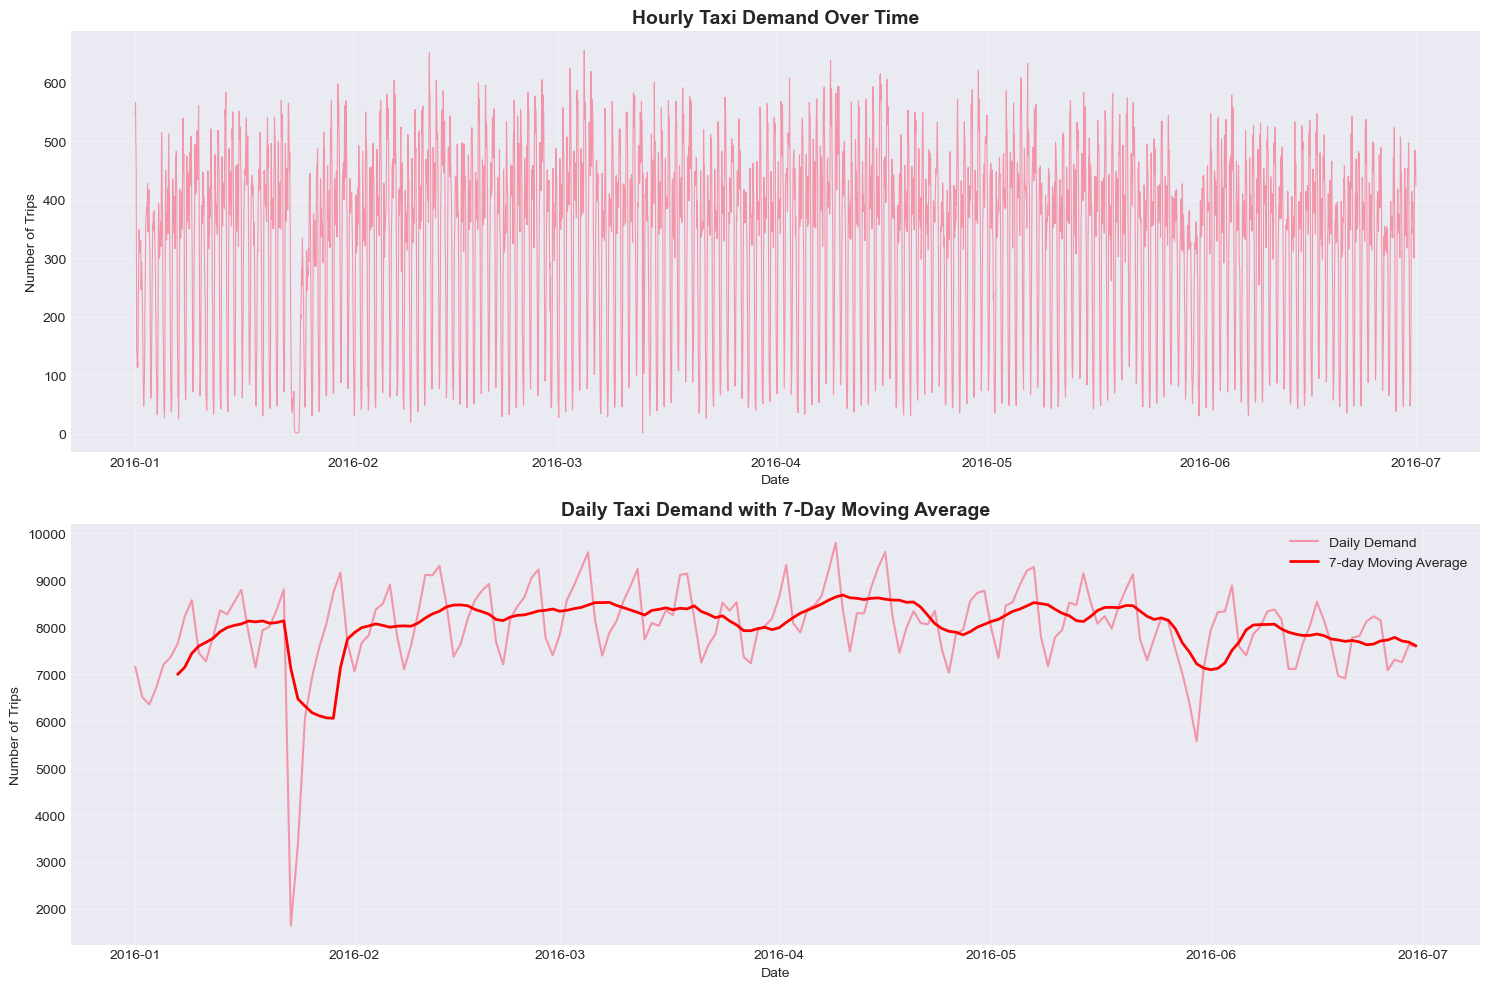

Time series plots saved!


In [7]:
# Plot hourly demand
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Hourly demand
axes[0].plot(hourly_demand.index, hourly_demand['demand'], linewidth=0.8, alpha=0.7)
axes[0].set_title('Hourly Taxi Demand Over Time', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Number of Trips')
axes[0].grid(True, alpha=0.3)

# Daily demand with rolling mean
axes[1].plot(daily_demand.index, daily_demand['demand'], label='Daily Demand', linewidth=1.5, alpha=0.7)
axes[1].plot(daily_demand.index, daily_demand['demand'].rolling(window=7).mean(), 
             label='7-day Moving Average', linewidth=2, color='red')
axes[1].set_title('Daily Taxi Demand with 7-Day Moving Average', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Number of Trips')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('demand_time_series.png', dpi=300, bbox_inches='tight')
plt.show()

print("Time series plots saved!")

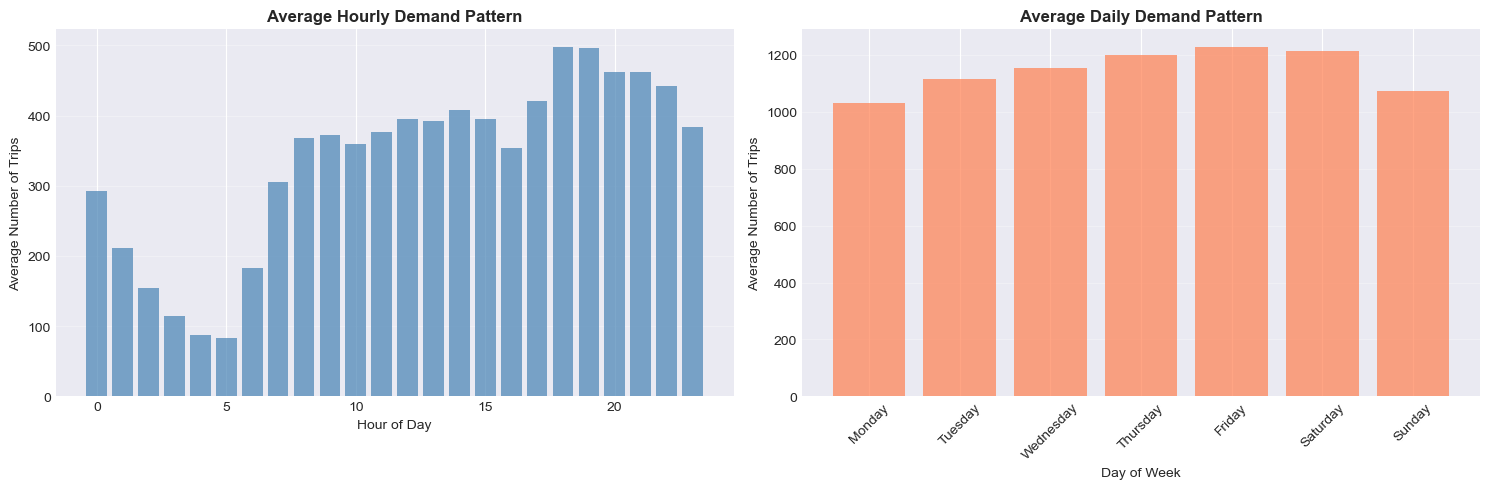

In [8]:
# Analyze patterns: Hour of day, Day of week
df['hour'] = df['pickup_datetime'].dt.hour
df['day_of_week'] = df['pickup_datetime'].dt.dayofweek
df['day_name'] = df['pickup_datetime'].dt.day_name()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Average demand by hour of day
hourly_pattern = df.groupby('hour').size() / len(df['pickup_date'].unique())
axes[0].bar(hourly_pattern.index, hourly_pattern.values, color='steelblue', alpha=0.7)
axes[0].set_title('Average Hourly Demand Pattern', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Average Number of Trips')
axes[0].grid(True, alpha=0.3, axis='y')

# Average demand by day of week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_pattern = df.groupby('day_name').size() / len(df['pickup_date'].unique())
daily_pattern = daily_pattern.reindex(day_order)
axes[1].bar(range(7), daily_pattern.values, color='coral', alpha=0.7)
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(day_order, rotation=45)
axes[1].set_title('Average Daily Demand Pattern', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Average Number of Trips')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('demand_patterns.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Time Series Decomposition and Stationarity Tests

In [9]:
# Install required packages
!pip install statsmodels pmdarima prophet scikit-learn tensorflow -q

Performing seasonal decomposition...


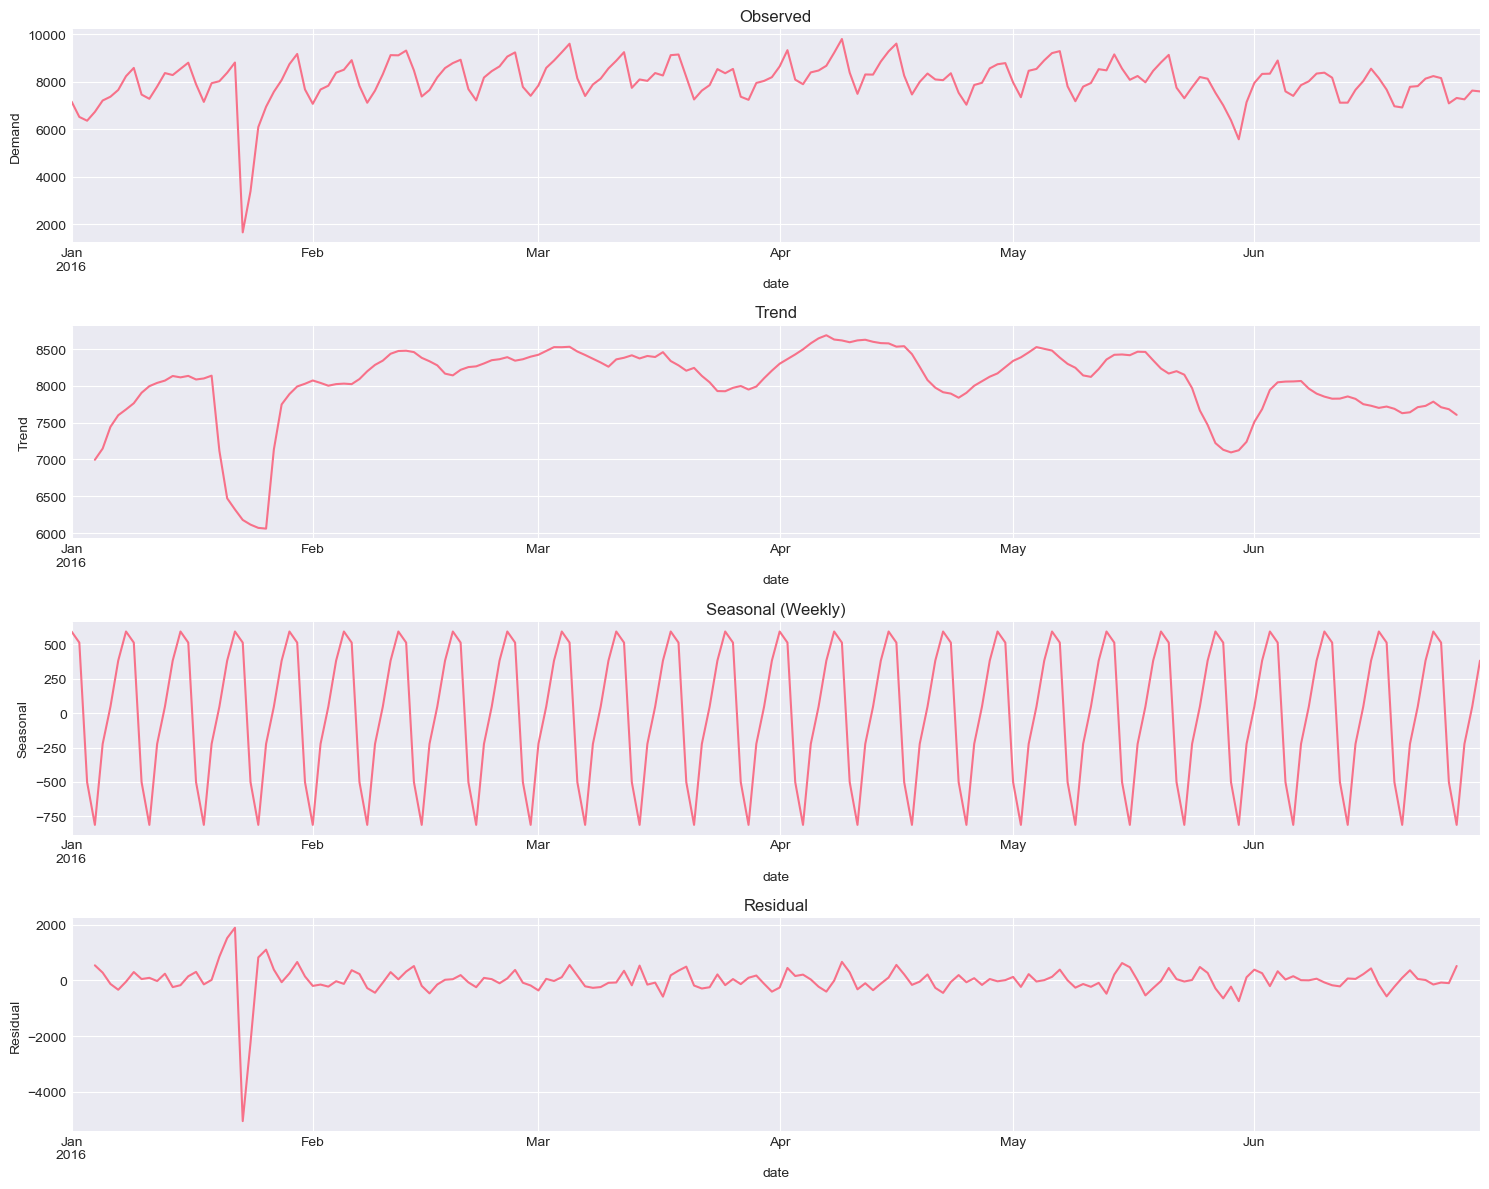

In [10]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Decompose the daily time series
print("Performing seasonal decomposition...")
decomposition = seasonal_decompose(daily_demand['demand'], model='additive', period=7)

fig, axes = plt.subplots(4, 1, figsize=(15, 12))

decomposition.observed.plot(ax=axes[0], title='Observed')
axes[0].set_ylabel('Demand')

decomposition.trend.plot(ax=axes[1], title='Trend')
axes[1].set_ylabel('Trend')

decomposition.seasonal.plot(ax=axes[2], title='Seasonal (Weekly)')
axes[2].set_ylabel('Seasonal')

decomposition.resid.plot(ax=axes[3], title='Residual')
axes[3].set_ylabel('Residual')

plt.tight_layout()
plt.savefig('time_series_decomposition.png', dpi=300, bbox_inches='tight')
plt.show()

In [11]:
# Augmented Dickey-Fuller test for stationarity
def adf_test(series, name=''):
    result = adfuller(series.dropna())
    print(f'ADF Test for {name}')
    print(f'ADF Statistic: {result[0]:.6f}')
    print(f'p-value: {result[1]:.6f}')
    print(f'Critical Values:')
    for key, value in result[4].items():
        print(f'   {key}: {value:.3f}')
    
    if result[1] <= 0.05:
        print("=> Series is STATIONARY (reject null hypothesis)\n")
    else:
        print("=> Series is NON-STATIONARY (fail to reject null hypothesis)\n")
    return result[1]

# Test original series
adf_test(daily_demand['demand'], 'Original Daily Demand')

# Test differenced series
daily_demand_diff = daily_demand['demand'].diff().dropna()
adf_test(daily_demand_diff, 'Differenced Daily Demand')

ADF Test for Original Daily Demand
ADF Statistic: -3.511274
p-value: 0.007702
Critical Values:
   1%: -3.468
   5%: -2.878
   10%: -2.576
=> Series is STATIONARY (reject null hypothesis)

ADF Test for Differenced Daily Demand
ADF Statistic: -6.656737
p-value: 0.000000
Critical Values:
   1%: -3.470
   5%: -2.879
   10%: -2.576
=> Series is STATIONARY (reject null hypothesis)



np.float64(4.962434536552761e-09)

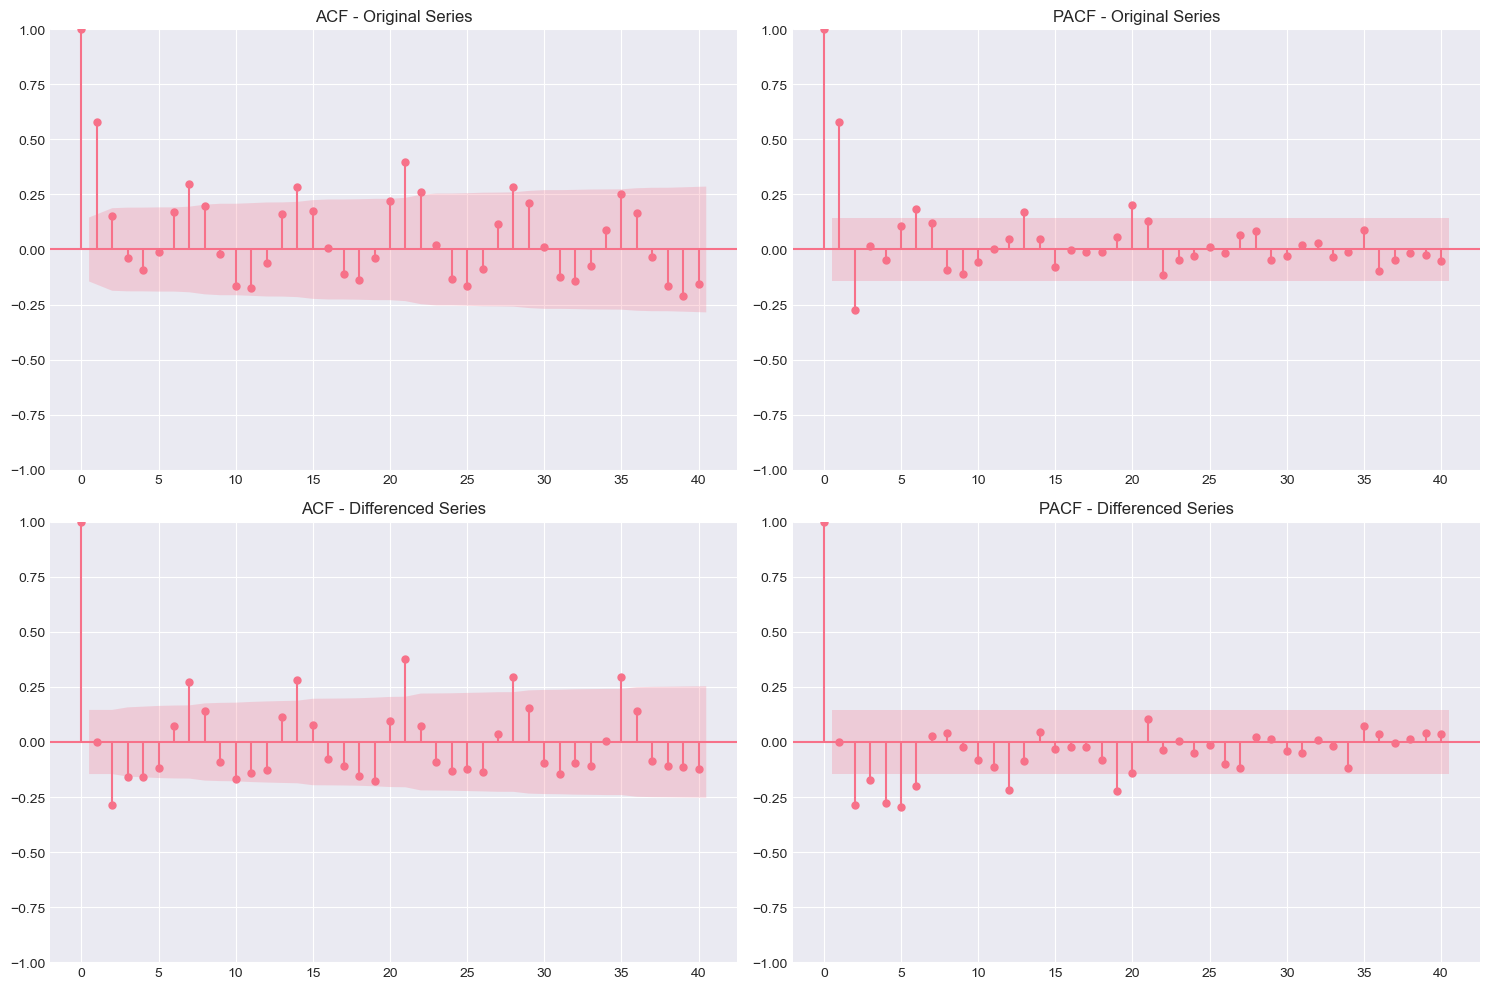

In [12]:
# ACF and PACF plots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Original series
plot_acf(daily_demand['demand'].dropna(), lags=40, ax=axes[0, 0])
axes[0, 0].set_title('ACF - Original Series')

plot_pacf(daily_demand['demand'].dropna(), lags=40, ax=axes[0, 1])
axes[0, 1].set_title('PACF - Original Series')

# Differenced series
plot_acf(daily_demand_diff, lags=40, ax=axes[1, 0])
axes[1, 0].set_title('ACF - Differenced Series')

plot_pacf(daily_demand_diff, lags=40, ax=axes[1, 1])
axes[1, 1].set_title('PACF - Differenced Series')

plt.tight_layout()
plt.savefig('acf_pacf_plots.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Train-Test Split

Training set: 145 days (2016-01-01 00:00:00 to 2016-05-24 00:00:00)
Test set: 37 days (2016-05-25 00:00:00 to 2016-06-30 00:00:00)


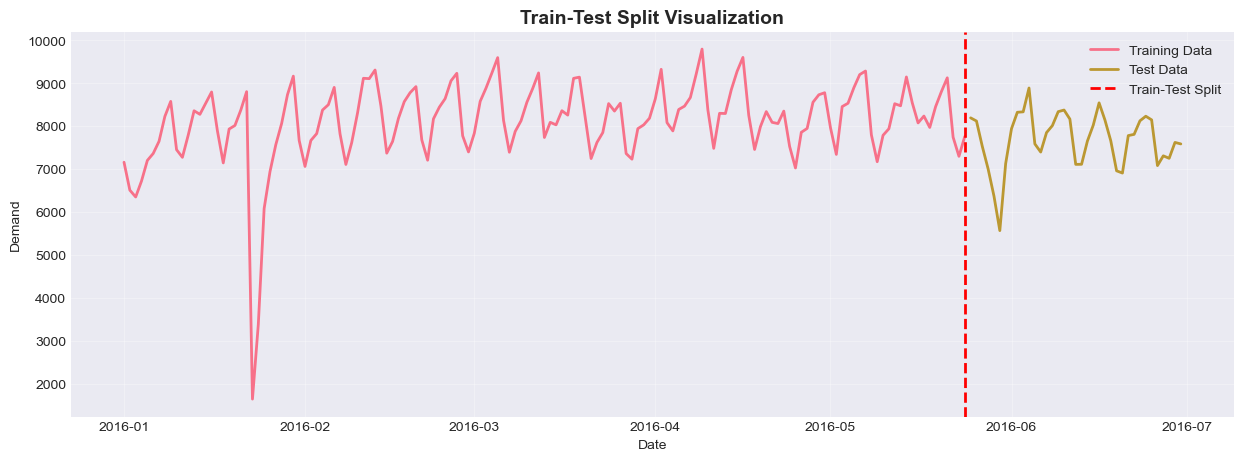

In [13]:
# Split data: 80% train, 20% test
train_size = int(len(daily_demand) * 0.8)
train_data = daily_demand[:train_size]
test_data = daily_demand[train_size:]

print(f"Training set: {len(train_data)} days ({train_data.index.min()} to {train_data.index.max()})")
print(f"Test set: {len(test_data)} days ({test_data.index.min()} to {test_data.index.max()})")

# Visualize split
plt.figure(figsize=(15, 5))
plt.plot(train_data.index, train_data['demand'], label='Training Data', linewidth=2)
plt.plot(test_data.index, test_data['demand'], label='Test Data', linewidth=2)
plt.axvline(x=train_data.index[-1], color='red', linestyle='--', linewidth=2, label='Train-Test Split')
plt.title('Train-Test Split Visualization', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Demand')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('train_test_split.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Model 1: SARIMA (Seasonal ARIMA)

In [14]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import time

print("Training SARIMA model...")
start_time = time.time()

# SARIMA parameters: (p,d,q) x (P,D,Q,s)
# Based on ACF/PACF and weekly seasonality (s=7)
order = (1, 1, 1)
seasonal_order = (1, 1, 1, 7)

sarima_model = SARIMAX(train_data['demand'], 
                       order=order, 
                       seasonal_order=seasonal_order,
                       enforce_stationarity=False,
                       enforce_invertibility=False)

sarima_fit = sarima_model.fit(disp=False)

print(f"SARIMA model trained in {time.time() - start_time:.2f} seconds")
print("\nModel Summary:")
print(sarima_fit.summary())

Training SARIMA model...


C:\Users\prash\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\prash\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


SARIMA model trained in 1.44 seconds

Model Summary:
                                     SARIMAX Results                                     
Dep. Variable:                            demand   No. Observations:                  145
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood               -1028.671
Date:                           Wed, 14 Jan 2026   AIC                           2067.341
Time:                                   22:05:38   BIC                           2081.602
Sample:                               01-01-2016   HQIC                          2073.135
                                    - 05-24-2016                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5312      0.085      6.222      0.000       0.364   

In [15]:
# Make predictions
sarima_pred = sarima_fit.forecast(steps=len(test_data))

# Calculate metrics
sarima_rmse = np.sqrt(mean_squared_error(test_data['demand'], sarima_pred))
sarima_mae = mean_absolute_error(test_data['demand'], sarima_pred)
sarima_mape = mean_absolute_percentage_error(test_data['demand'], sarima_pred) * 100

print(f"SARIMA Model Performance:")
print(f"RMSE: {sarima_rmse:.2f}")
print(f"MAE: {sarima_mae:.2f}")
print(f"MAPE: {sarima_mape:.2f}%")

SARIMA Model Performance:
RMSE: 926.07
MAE: 777.55
MAPE: 10.61%


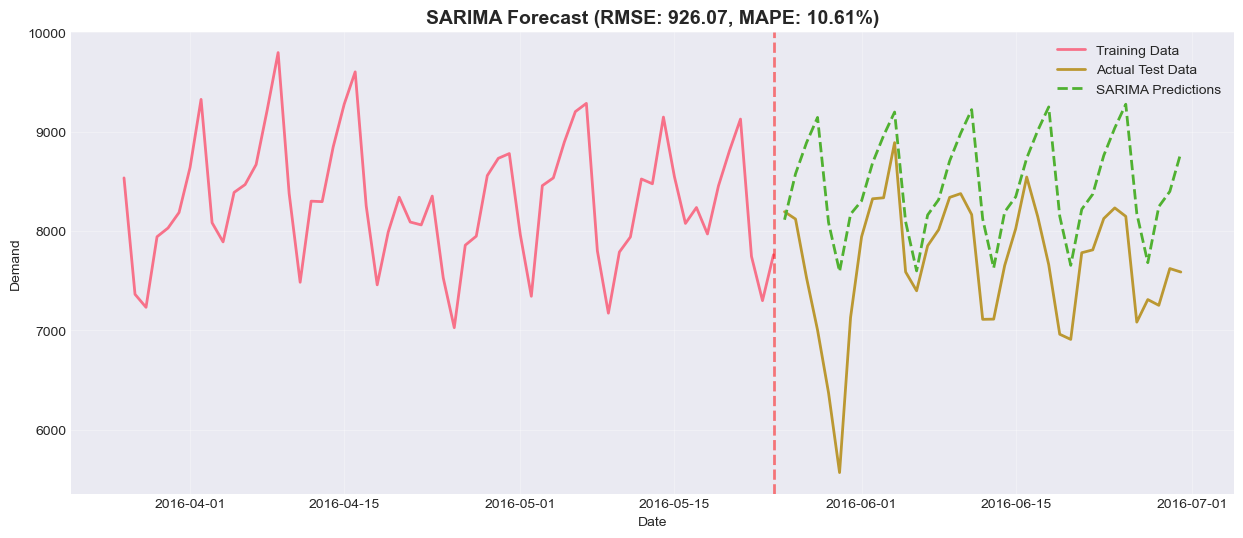

In [16]:
# Plot SARIMA predictions
plt.figure(figsize=(15, 6))
plt.plot(train_data.index[-60:], train_data['demand'][-60:], label='Training Data', linewidth=2)
plt.plot(test_data.index, test_data['demand'], label='Actual Test Data', linewidth=2)
plt.plot(test_data.index, sarima_pred, label='SARIMA Predictions', linewidth=2, linestyle='--')
plt.axvline(x=train_data.index[-1], color='red', linestyle='--', alpha=0.5, linewidth=2)
plt.title(f'SARIMA Forecast (RMSE: {sarima_rmse:.2f}, MAPE: {sarima_mape:.2f}%)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Demand')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('sarima_predictions.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Model 2: Auto ARIMA (Automated Parameter Selection)

In [17]:
import time
from pmdarima import auto_arima

print("Training Auto ARIMA model (this may take a few minutes)...")
start_time = time.time()

auto_model = auto_arima(
    train_data['demand'],
    start_p=0, start_q=0,
    max_p=3, max_q=3,
    m=7,                  # weekly seasonality
    start_P=0, start_Q=0,
    max_P=2, max_Q=2,
    seasonal=True,
    d=None, D=None,       # auto determine differencing
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)

print(f"\nAuto ARIMA completed in {time.time() - start_time:.2f} seconds")
print("\nBest Model:")
print(auto_model.summary())


Training Auto ARIMA model (this may take a few minutes)...
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=2373.156, Time=0.06 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=2367.833, Time=0.13 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=2369.177, Time=0.36 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=2371.162, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[7] intercept   : AIC=2375.008, Time=0.05 sec
 ARIMA(1,1,0)(2,0,0)[7] intercept   : AIC=2362.894, Time=0.56 sec
 ARIMA(1,1,0)(2,0,1)[7] intercept   : AIC=2346.191, Time=1.38 sec
 ARIMA(1,1,0)(1,0,1)[7] intercept   : AIC=2344.871, Time=0.80 sec
 ARIMA(1,1,0)(0,0,1)[7] intercept   : AIC=2370.253, Time=0.12 sec
 ARIMA(1,1,0)(1,0,2)[7] intercept   : AIC=2345.523, Time=1.24 sec
 ARIMA(1,1,0)(0,0,2)[7] intercept   : AIC=2369.237, Time=0.24 sec
 ARIMA(1,1,0)(2,0,2)[7] intercept   : AIC=2350.462, Time=1.59 sec
 ARIMA(0,1,0)(1,0,1)[7] intercept   : AIC=2345.441, Time=0.86 sec
 ARIMA(2,1,0)(1,0,1)[7] intercept   : AI

In [18]:
# Make predictions with Auto ARIMA
auto_pred = auto_model.predict(n_periods=len(test_data))

# Calculate metrics
auto_rmse = np.sqrt(mean_squared_error(test_data['demand'], auto_pred))
auto_mae = mean_absolute_error(test_data['demand'], auto_pred)
auto_mape = mean_absolute_percentage_error(test_data['demand'], auto_pred) * 100

print(f"Auto ARIMA Model Performance:")
print(f"RMSE: {auto_rmse:.2f}")
print(f"MAE: {auto_mae:.2f}")
print(f"MAPE: {auto_mape:.2f}%")

Auto ARIMA Model Performance:
RMSE: 847.89
MAE: 687.20
MAPE: 9.55%


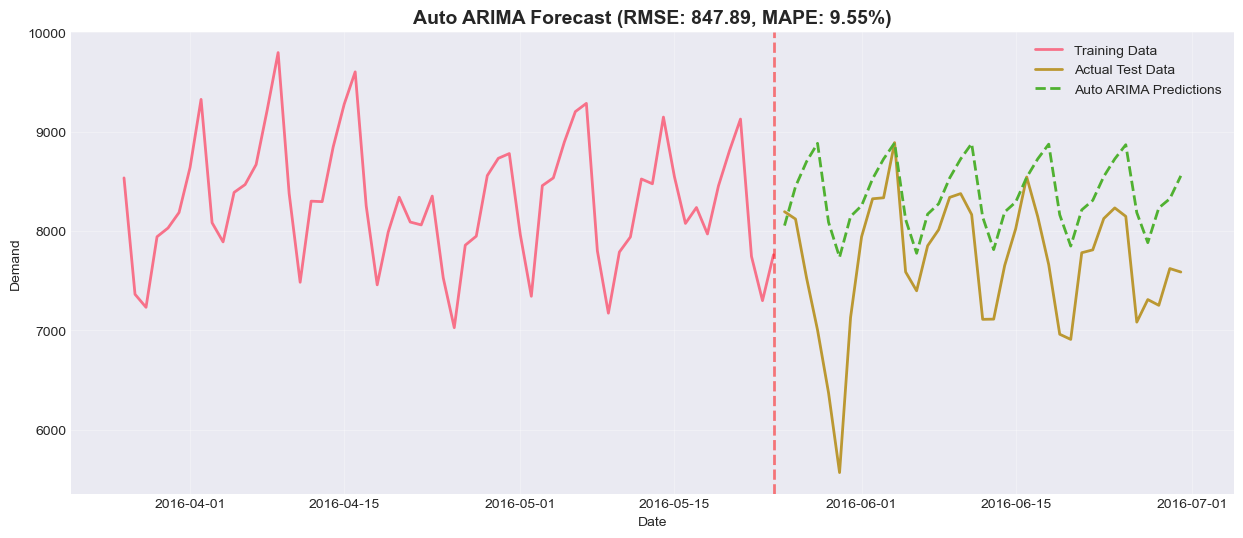

In [19]:
# Plot Auto ARIMA predictions
plt.figure(figsize=(15, 6))
plt.plot(train_data.index[-60:], train_data['demand'][-60:], label='Training Data', linewidth=2)
plt.plot(test_data.index, test_data['demand'], label='Actual Test Data', linewidth=2)
plt.plot(test_data.index, auto_pred, label='Auto ARIMA Predictions', linewidth=2, linestyle='--')
plt.axvline(x=train_data.index[-1], color='red', linestyle='--', alpha=0.5, linewidth=2)
plt.title(f'Auto ARIMA Forecast (RMSE: {auto_rmse:.2f}, MAPE: {auto_mape:.2f}%)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Demand')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('auto_arima_predictions.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Model 3: Facebook Prophet

In [20]:
from prophet import Prophet

# Prepare data for Prophet (requires 'ds' and 'y' columns)
train_prophet = train_data.reset_index()
train_prophet.columns = ['ds', 'y']

test_prophet = test_data.reset_index()
test_prophet.columns = ['ds', 'y']

print("Training Prophet model...")
start_time = time.time()

prophet_model = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True,
    seasonality_mode='additive',
    changepoint_prior_scale=0.05
)

prophet_model.fit(train_prophet)

print(f"Prophet model trained in {time.time() - start_time:.2f} seconds")

Training Prophet model...


22:07:45 - cmdstanpy - INFO - Chain [1] start processing
22:07:45 - cmdstanpy - INFO - Chain [1] done processing


Prophet model trained in 0.76 seconds


In [21]:
# Make predictions
future = prophet_model.make_future_dataframe(periods=len(test_data), freq='D')
prophet_forecast = prophet_model.predict(future)

# Extract predictions for test period
prophet_pred = prophet_forecast.tail(len(test_data))['yhat'].values

# Calculate metrics
prophet_rmse = np.sqrt(mean_squared_error(test_data['demand'], prophet_pred))
prophet_mae = mean_absolute_error(test_data['demand'], prophet_pred)
prophet_mape = mean_absolute_percentage_error(test_data['demand'], prophet_pred) * 100

print(f"Prophet Model Performance:")
print(f"RMSE: {prophet_rmse:.2f}")
print(f"MAE: {prophet_mae:.2f}")
print(f"MAPE: {prophet_mape:.2f}%")

Prophet Model Performance:
RMSE: 4227.97
MAE: 3711.86
MAPE: 48.46%


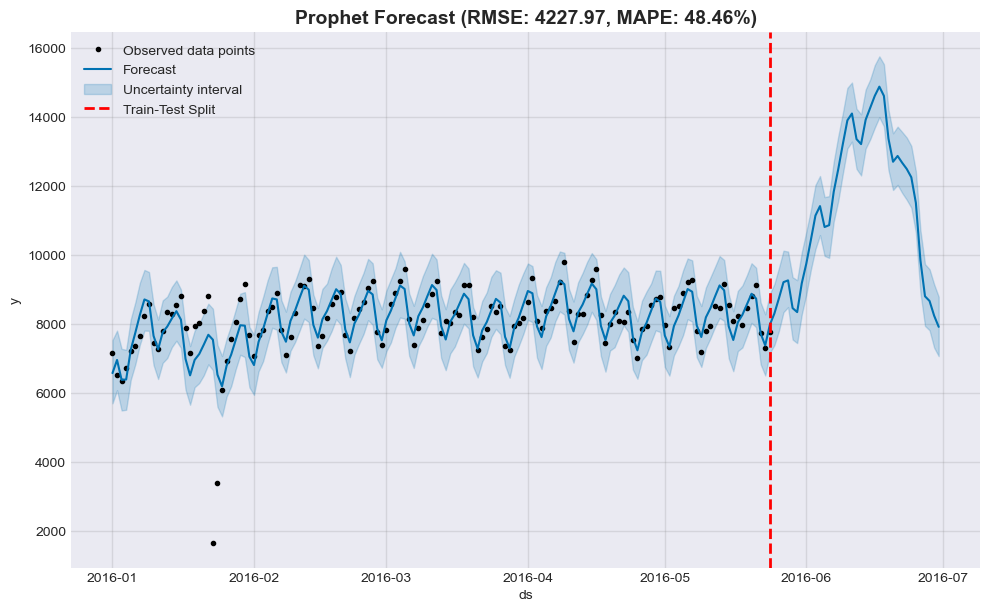

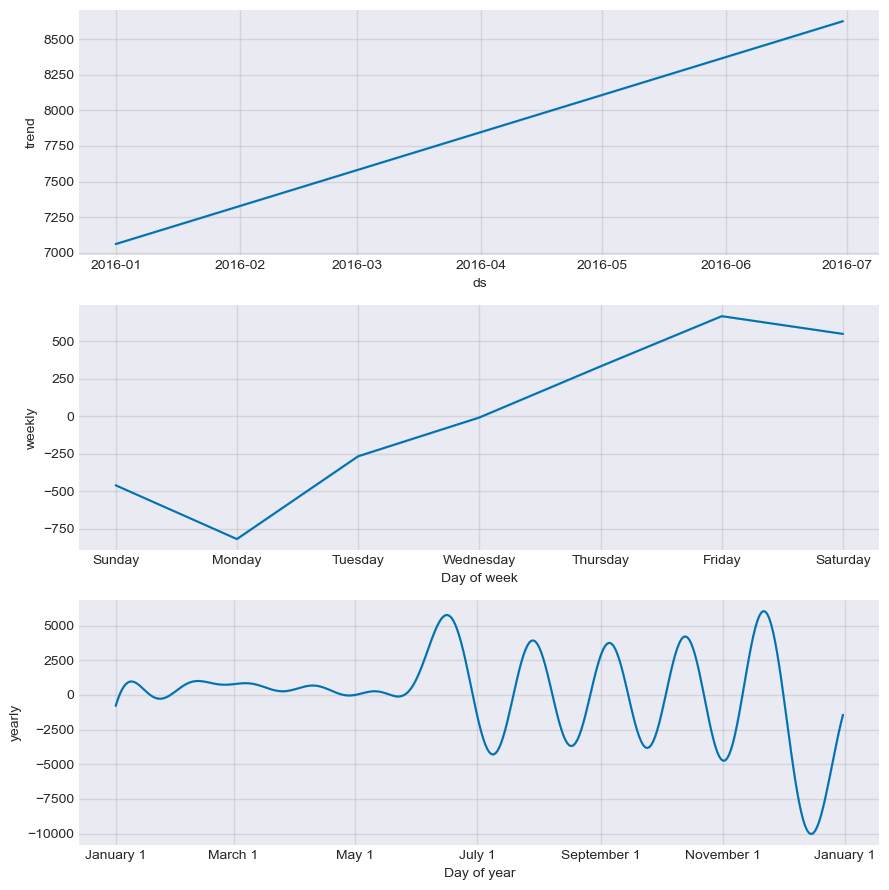

In [22]:
# Plot Prophet predictions
fig = prophet_model.plot(prophet_forecast)
plt.axvline(x=train_data.index[-1], color='red', linestyle='--', linewidth=2, label='Train-Test Split')
plt.title(f'Prophet Forecast (RMSE: {prophet_rmse:.2f}, MAPE: {prophet_mape:.2f}%)', 
          fontsize=14, fontweight='bold')
plt.legend()
plt.savefig('prophet_predictions.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot components
fig2 = prophet_model.plot_components(prophet_forecast)
plt.savefig('prophet_components.png', dpi=300, bbox_inches='tight')
plt.show()

## 9. Model 4: LSTM Neural Network

In [23]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Prepare data for LSTM
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(daily_demand[['demand']])

# Create sequences
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 14  # Use 14 days to predict next day
X, y = create_sequences(scaled_data, seq_length)

# Split based on original train-test split
train_size_lstm = train_size - seq_length
X_train, X_test = X[:train_size_lstm], X[train_size_lstm:]
y_train, y_test = y[:train_size_lstm], y[train_size_lstm:]

print(f"LSTM Training data shape: {X_train.shape}")
print(f"LSTM Test data shape: {X_test.shape}")

LSTM Training data shape: (131, 14, 1)
LSTM Test data shape: (37, 14, 1)


In [24]:
# Build LSTM model
print("Building LSTM model...")

lstm_model = Sequential([
    LSTM(64, activation='relu', return_sequences=True, input_shape=(seq_length, 1)),
    Dropout(0.2),
    LSTM(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
lstm_model.summary()

Building LSTM model...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 14, 64)              │          16,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 14, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
# Train LSTM model
print("Training LSTM model...")
start_time = time.time()

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = lstm_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

print(f"\nLSTM model trained in {time.time() - start_time:.2f} seconds")

Training LSTM model...
Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 261ms/step - loss: 0.6846 - mae: 0.8173 - val_loss: 0.6535 - val_mae: 0.8052
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.6110 - mae: 0.7713 - val_loss: 0.5765 - val_mae: 0.7559
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.5483 - mae: 0.7305 - val_loss: 0.5132 - val_mae: 0.7128
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.4825 - mae: 0.6850 - val_loss: 0.4385 - val_mae: 0.6582
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.4022 - mae: 0.6244 - val_loss: 0.3393 - val_mae: 0.5780
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.3073 - mae: 0.5435 - val_loss: 0.1991 - val_mae: 0.4402
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.1704 - mae: 0.3941 - val_loss: 0.0422 - val_mae: 0.1918
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0570 - mae: 0.1945 - val_loss: 0.0656 - val_mae: 0.2447
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/ste

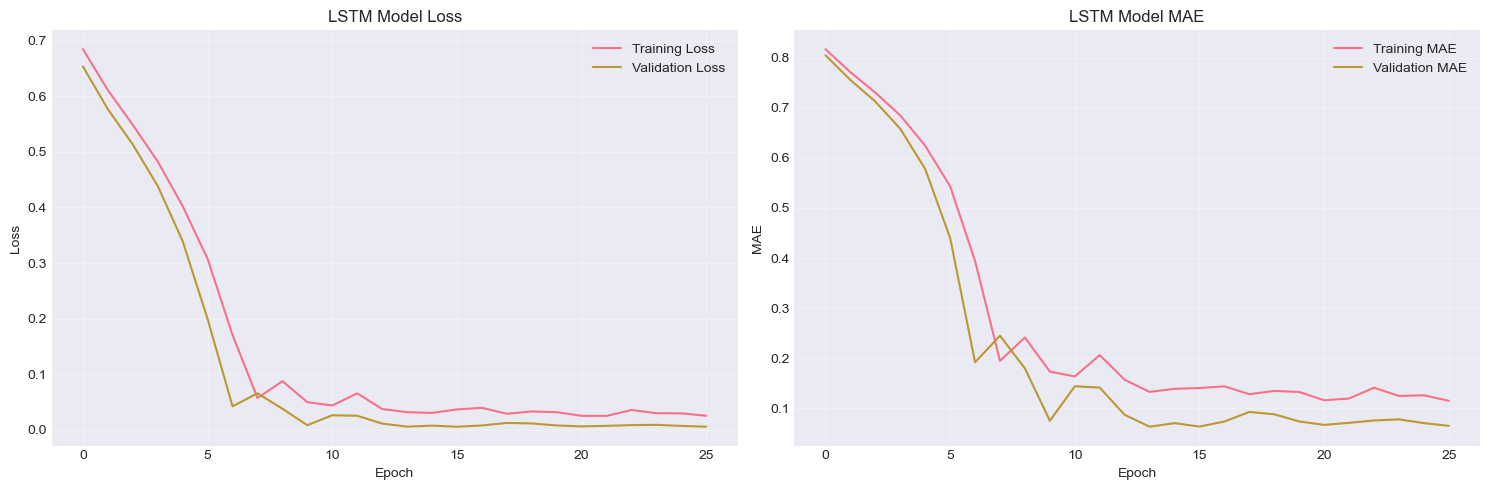

In [26]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(history.history['loss'], label='Training Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_title('LSTM Model Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['mae'], label='Training MAE')
axes[1].plot(history.history['val_mae'], label='Validation MAE')
axes[1].set_title('LSTM Model MAE')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lstm_training_history.png', dpi=300, bbox_inches='tight')
plt.show()

In [27]:
# Make predictions with LSTM
lstm_pred_scaled = lstm_model.predict(X_test)
lstm_pred = scaler.inverse_transform(lstm_pred_scaled)
y_test_actual = scaler.inverse_transform(y_test)

# Calculate metrics
lstm_rmse = np.sqrt(mean_squared_error(y_test_actual, lstm_pred))
lstm_mae = mean_absolute_error(y_test_actual, lstm_pred)
lstm_mape = mean_absolute_percentage_error(y_test_actual, lstm_pred) * 100

print(f"LSTM Model Performance:")
print(f"RMSE: {lstm_rmse:.2f}")
print(f"MAE: {lstm_mae:.2f}")
print(f"MAPE: {lstm_mape:.2f}%")

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 515ms/step
LSTM Model Performance:
RMSE: 810.85
MAE: 601.24
MAPE: 8.47%


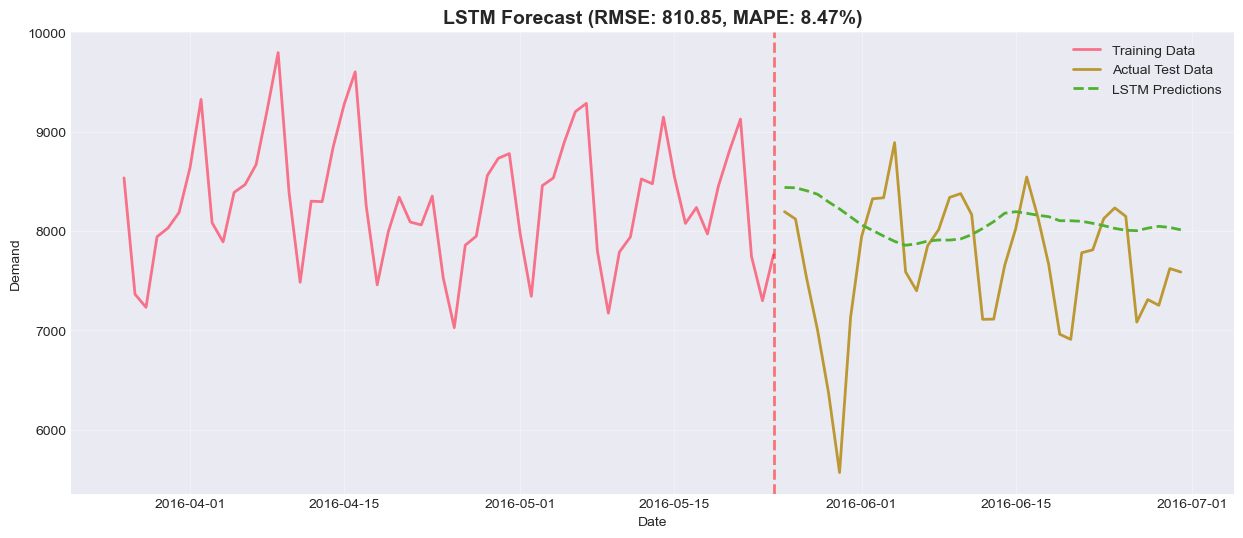

In [28]:
# Plot LSTM predictions
test_dates = daily_demand.index[train_size:train_size+len(y_test_actual)]

plt.figure(figsize=(15, 6))
plt.plot(train_data.index[-60:], train_data['demand'][-60:], label='Training Data', linewidth=2)
plt.plot(test_dates, y_test_actual, label='Actual Test Data', linewidth=2)
plt.plot(test_dates, lstm_pred, label='LSTM Predictions', linewidth=2, linestyle='--')
plt.axvline(x=train_data.index[-1], color='red', linestyle='--', alpha=0.5, linewidth=2)
plt.title(f'LSTM Forecast (RMSE: {lstm_rmse:.2f}, MAPE: {lstm_mape:.2f}%)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Demand')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('lstm_predictions.png', dpi=300, bbox_inches='tight')
plt.show()

## 10. Model Comparison and Results

In [29]:
# Create comparison dataframe
results = pd.DataFrame({
    'Model': ['SARIMA', 'Auto ARIMA', 'Prophet', 'LSTM'],
    'RMSE': [sarima_rmse, auto_rmse, prophet_rmse, lstm_rmse],
    'MAE': [sarima_mae, auto_mae, prophet_mae, lstm_mae],
    'MAPE (%)': [sarima_mape, auto_mape, prophet_mape, lstm_mape]
})

results = results.sort_values('RMSE')
print("\n" + "="*60)
print("MODEL COMPARISON RESULTS")
print("="*60)
print(results.to_string(index=False))
print("="*60)

# Save results
results.to_csv('model_comparison_results.csv', index=False)
print("\nResults saved to 'model_comparison_results.csv'")


MODEL COMPARISON RESULTS
     Model        RMSE         MAE  MAPE (%)
      LSTM  810.849502  601.236724  8.471268
Auto ARIMA  847.892079  687.204953  9.545908
    SARIMA  926.065834  777.554773 10.614986
   Prophet 4227.974946 3711.863571 48.461483

Results saved to 'model_comparison_results.csv'


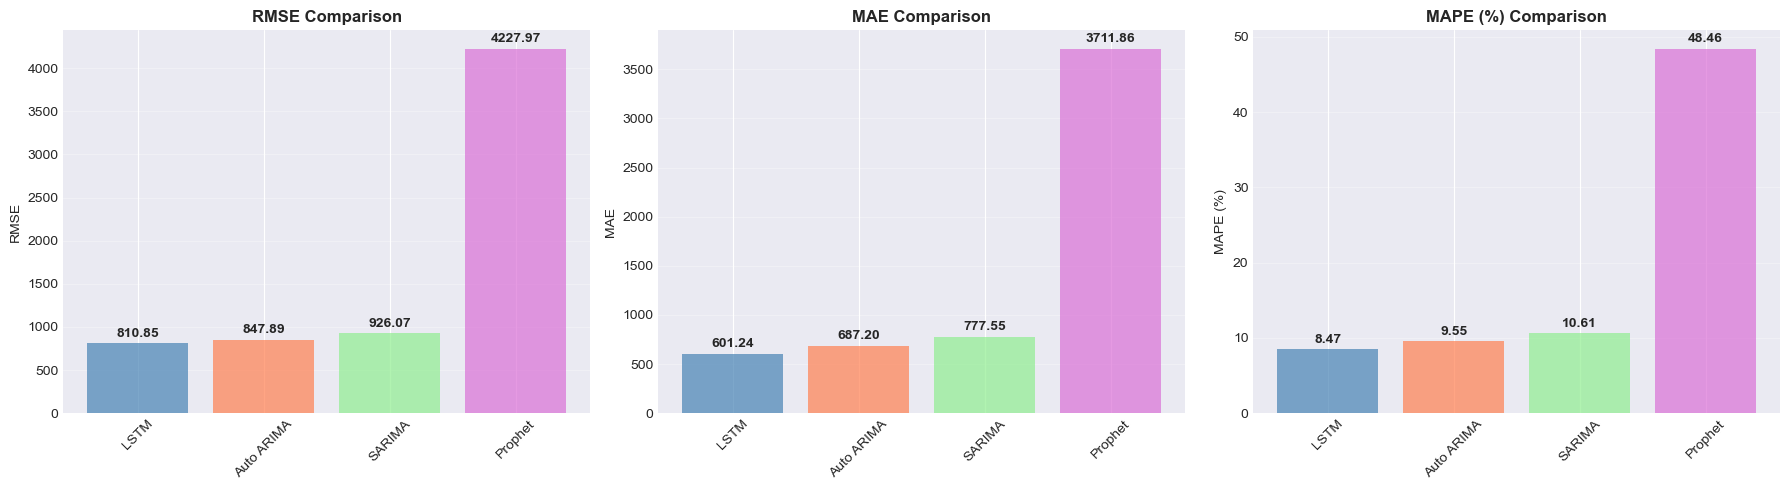

In [30]:
# Visualize model comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = ['RMSE', 'MAE', 'MAPE (%)']
colors = ['steelblue', 'coral', 'lightgreen', 'orchid']

for i, metric in enumerate(metrics):
    axes[i].bar(results['Model'], results[metric], color=colors, alpha=0.7)
    axes[i].set_title(f'{metric} Comparison', fontsize=12, fontweight='bold')
    axes[i].set_ylabel(metric)
    axes[i].grid(True, alpha=0.3, axis='y')
    axes[i].tick_params(axis='x', rotation=45)
    
    # Add value labels on bars
    for j, v in enumerate(results[metric]):
        axes[i].text(j, v + 0.01*max(results[metric]), f'{v:.2f}', 
                    ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

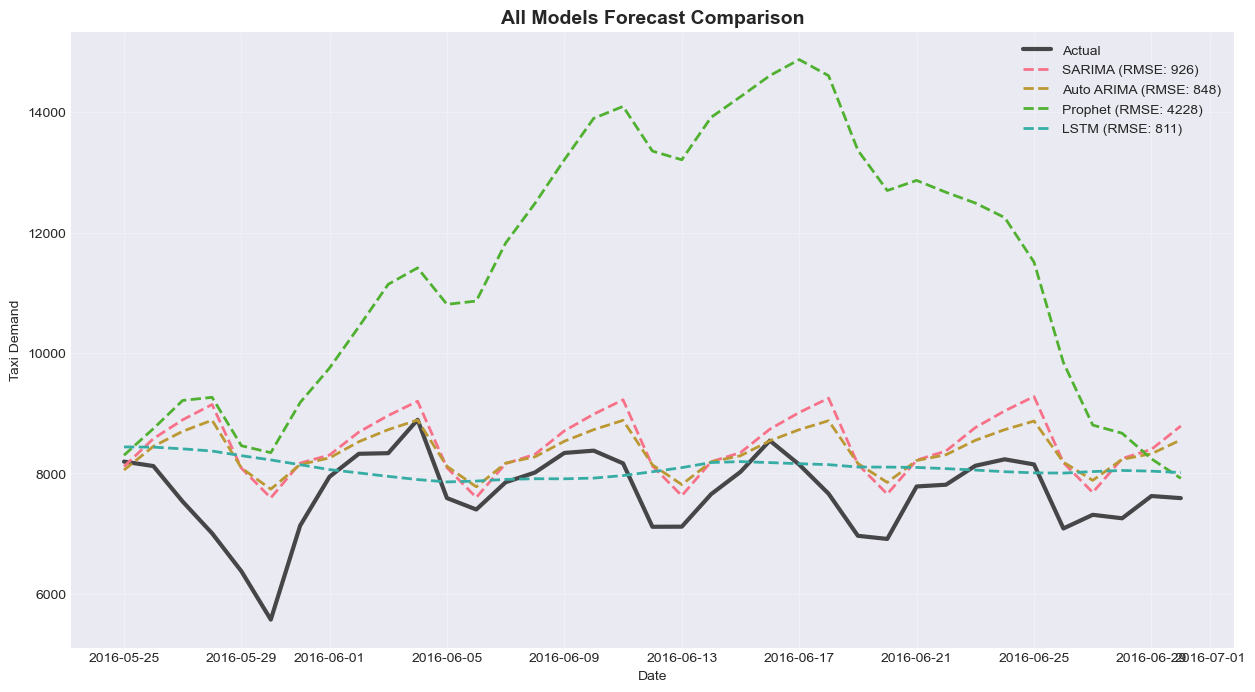

In [31]:
# Compare all predictions visually
plt.figure(figsize=(15, 8))
plt.plot(test_data.index, test_data['demand'], label='Actual', linewidth=3, color='black', alpha=0.7)
plt.plot(test_data.index, sarima_pred, label=f'SARIMA (RMSE: {sarima_rmse:.0f})', linewidth=2, linestyle='--')
plt.plot(test_data.index, auto_pred, label=f'Auto ARIMA (RMSE: {auto_rmse:.0f})', linewidth=2, linestyle='--')
plt.plot(test_data.index, prophet_pred, label=f'Prophet (RMSE: {prophet_rmse:.0f})', linewidth=2, linestyle='--')
plt.plot(test_dates, lstm_pred, label=f'LSTM (RMSE: {lstm_rmse:.0f})', linewidth=2, linestyle='--')

plt.title('All Models Forecast Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Taxi Demand')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.savefig('all_models_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## 11. Future Predictions (Next 30 Days)

In [32]:
# Select best model based on RMSE
best_model_name = results.iloc[0]['Model']
print(f"Best performing model: {best_model_name}\n")

# Generate future predictions with the best model
future_days = 30
print(f"Generating {future_days}-day forecast using {best_model_name}...\n")

if best_model_name == 'SARIMA':
    # Retrain on full dataset
    final_model = SARIMAX(daily_demand['demand'], 
                          order=order, 
                          seasonal_order=seasonal_order,
                          enforce_stationarity=False,
                          enforce_invertibility=False)
    final_fit = final_model.fit(disp=False)
    future_pred = final_fit.forecast(steps=future_days)
    
elif best_model_name == 'Auto ARIMA':
    # Retrain on full dataset
    auto_model.fit(daily_demand['demand'])
    future_pred = auto_model.predict(n_periods=future_days)
    
elif best_model_name == 'Prophet':
    # Retrain on full dataset
    full_prophet = daily_demand.reset_index()
    full_prophet.columns = ['ds', 'y']
    prophet_model = Prophet(
        daily_seasonality=False,
        weekly_seasonality=True,
        yearly_seasonality=True,
        seasonality_mode='additive',
        changepoint_prior_scale=0.05
    )
    prophet_model.fit(full_prophet)
    future = prophet_model.make_future_dataframe(periods=future_days, freq='D')
    forecast = prophet_model.predict(future)
    future_pred = forecast.tail(future_days)['yhat'].values
    
else:  # LSTM
    # Retrain on full dataset
    X_full, y_full = create_sequences(scaled_data, seq_length)
    lstm_model.fit(X_full, y_full, epochs=50, batch_size=32, verbose=0)
    
    # Predict iteratively
    future_pred = []
    current_seq = scaled_data[-seq_length:].copy()
    
    for _ in range(future_days):
        pred = lstm_model.predict(current_seq.reshape(1, seq_length, 1), verbose=0)
        future_pred.append(pred[0, 0])
        current_seq = np.append(current_seq[1:], pred)
    
    future_pred = scaler.inverse_transform(np.array(future_pred).reshape(-1, 1)).flatten()

# Create future dates
last_date = daily_demand.index[-1]
future_dates = pd.date_range(start=last_date + timedelta(days=1), periods=future_days, freq='D')

# Create future forecast dataframe
future_forecast = pd.DataFrame({
    'Date': future_dates,
    'Predicted_Demand': future_pred
})

print("Future Demand Forecast:")
print(future_forecast.to_string(index=False))

# Save forecast
future_forecast.to_csv('future_demand_forecast.csv', index=False)
print("\nForecast saved to 'future_demand_forecast.csv'")

Best performing model: LSTM

Generating 30-day forecast using LSTM...

Future Demand Forecast:
      Date  Predicted_Demand
2016-07-01       7489.108398
2016-07-02       7470.524902
2016-07-03       7456.015625
2016-07-04       7461.417969
2016-07-05       7471.576172
2016-07-06       7466.583008
2016-07-07       7459.143555
2016-07-08       7442.352539
2016-07-09       7418.798828
2016-07-10       7399.988770
2016-07-11       7409.090820
2016-07-12       7413.145996
2016-07-13       7417.719238
2016-07-14       7412.467285
2016-07-15       7407.771973
2016-07-16       7405.217773
2016-07-17       7403.278809
2016-07-18       7401.866211
2016-07-19       7400.464355
2016-07-20       7398.776855
2016-07-21       7397.085449
2016-07-22       7395.486816
2016-07-23       7394.283203
2016-07-24       7393.711914
2016-07-25       7393.612305
2016-07-26       7393.252441
2016-07-27       7392.745605
2016-07-28       7392.092285
2016-07-29       7391.554199
2016-07-30       7391.127441

Forec

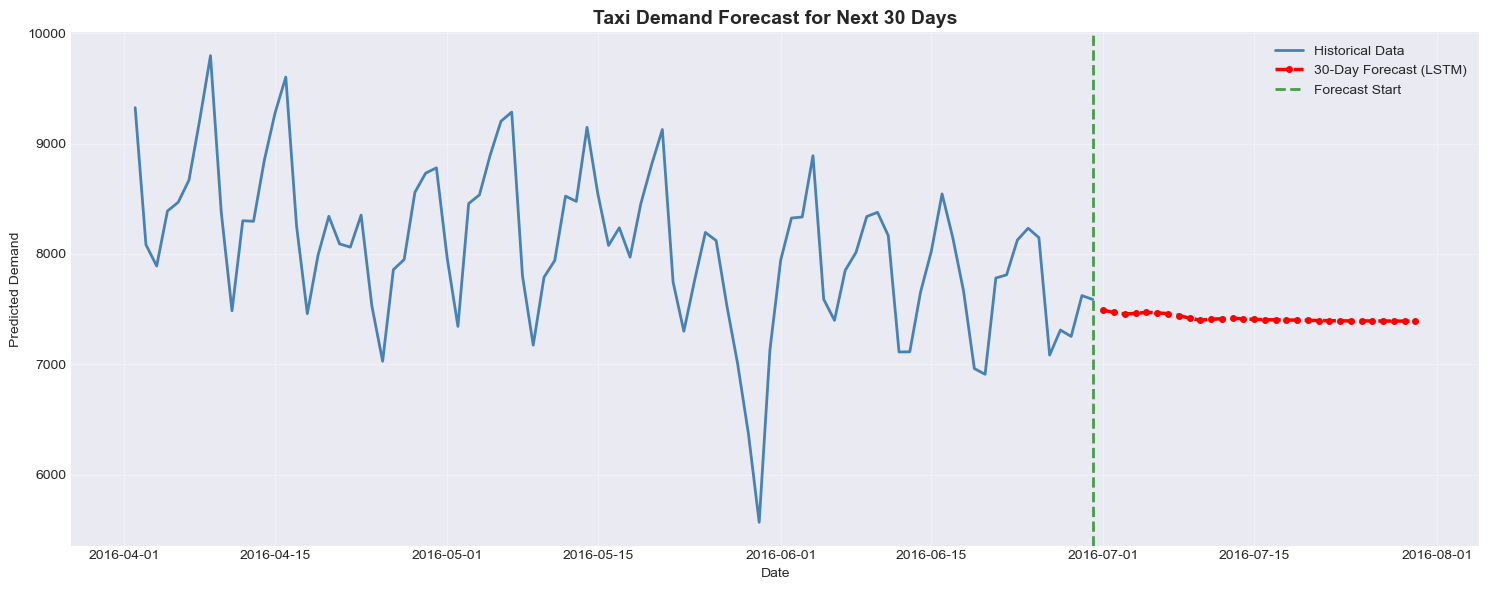

In [33]:
# Plot future forecast
plt.figure(figsize=(15, 6))
plt.plot(daily_demand.index[-90:], daily_demand['demand'][-90:], 
         label='Historical Data', linewidth=2, color='steelblue')
plt.plot(future_dates, future_pred, 
         label=f'{future_days}-Day Forecast ({best_model_name})', 
         linewidth=2.5, color='red', linestyle='--', marker='o', markersize=4)
plt.axvline(x=daily_demand.index[-1], color='green', linestyle='--', 
            linewidth=2, alpha=0.7, label='Forecast Start')
plt.title(f'Taxi Demand Forecast for Next {future_days} Days', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Predicted Demand')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('future_demand_forecast.png', dpi=300, bbox_inches='tight')
plt.show()

## 12. Summary and Insights

In [34]:
print("\n" + "="*80)
print("TAXI DEMAND FORECASTING - SUMMARY REPORT")
print("="*80)
print(f"\nDataset: {len(df):,} taxi trips")
print(f"Time Period: {df['pickup_datetime'].min().date()} to {df['pickup_datetime'].max().date()}")
print(f"Total Days: {len(daily_demand)} days")
print(f"\nAverage Daily Demand: {daily_demand['demand'].mean():.0f} trips")
print(f"Peak Daily Demand: {daily_demand['demand'].max():.0f} trips")
print(f"Lowest Daily Demand: {daily_demand['demand'].min():.0f} trips")

print("\n" + "-"*80)
print("KEY PATTERNS IDENTIFIED:")
print("-"*80)
print(f"• Busiest Hour: {hourly_pattern.idxmax()}:00 (avg {hourly_pattern.max():.0f} trips/hour)")
print(f"• Quietest Hour: {hourly_pattern.idxmin()}:00 (avg {hourly_pattern.min():.0f} trips/hour)")
print(f"• Busiest Day: {daily_pattern.idxmax()} (avg {daily_pattern.max():.0f} trips/day)")
print(f"• Quietest Day: {daily_pattern.idxmin()} (avg {daily_pattern.min():.0f} trips/day)")
print(f"• Weekly Seasonality: Strong (7-day cycle observed)")

print("\n" + "-"*80)
print("MODEL PERFORMANCE RANKING:")
print("-"*80)
for idx, row in results.iterrows():
    print(f"{idx+1}. {row['Model']:<15} - RMSE: {row['RMSE']:>8.2f}, MAE: {row['MAE']:>8.2f}, MAPE: {row['MAPE (%)']:>6.2f}%")

print(f"\n🏆 Best Model: {best_model_name}")

print("\n" + "-"*80)
print("FUTURE FORECAST SUMMARY:")
print("-"*80)
print(f"Forecast Period: {future_dates[0].date()} to {future_dates[-1].date()}")
print(f"Average Predicted Demand: {future_pred.mean():.0f} trips/day")
print(f"Peak Predicted Demand: {future_pred.max():.0f} trips/day on {future_dates[np.argmax(future_pred)].date()}")
print(f"Lowest Predicted Demand: {future_pred.min():.0f} trips/day on {future_dates[np.argmin(future_pred)].date()}")

print("\n" + "="*80)
print("BUSINESS RECOMMENDATIONS:")
print("="*80)
print("1. Resource Allocation: Deploy more taxis during peak hours and weekdays")
print("2. Dynamic Pricing: Implement surge pricing during high-demand periods")
print("3. Driver Scheduling: Optimize shift patterns based on hourly demand forecasts")
print("4. Fleet Management: Use weekly patterns to plan maintenance schedules")
print("5. Demand Response: Monitor real-time vs predicted demand for adjustments")
print("="*80)

print("\n✅ Analysis Complete! All results and visualizations have been saved.")


TAXI DEMAND FORECASTING - SUMMARY REPORT

Dataset: 1,458,644 taxi trips
Time Period: 2016-01-01 to 2016-06-30
Total Days: 182 days

Average Daily Demand: 8015 trips
Peak Daily Demand: 9796 trips
Lowest Daily Demand: 1648 trips

--------------------------------------------------------------------------------
KEY PATTERNS IDENTIFIED:
--------------------------------------------------------------------------------
• Busiest Hour: 18:00 (avg 498 trips/hour)
• Quietest Hour: 5:00 (avg 82 trips/hour)
• Busiest Day: Friday (avg 1228 trips/day)
• Quietest Day: Monday (avg 1030 trips/day)
• Weekly Seasonality: Strong (7-day cycle observed)

--------------------------------------------------------------------------------
MODEL PERFORMANCE RANKING:
--------------------------------------------------------------------------------
4. LSTM            - RMSE:   810.85, MAE:   601.24, MAPE:   8.47%
2. Auto ARIMA      - RMSE:   847.89, MAE:   687.20, MAPE:   9.55%
1. SARIMA          - RMSE:   926.07, M